#                              **AI4005: Mini Project**
##                      **Fast Incremental GMM Clustering Algorithm**
### Anirudh Srinivasan (CS20BTECH11059) | Ajit Shankar (ES20BTECH11003)

## Importing Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

## FIGM Class

In [1]:
class GaussianComponent:
    def __init__(self, x, dimension, init_variance=0.01):
        self.mean = np.copy(x)
        self.precision = np.linalg.inv(init_variance * np.eye(dimension))
        self.age = 1
        self.accumulator = 1
        self.prior = 1

def mahalanobis_distance(x, component):
    diff = x - component.mean
    return np.dot(diff, np.dot(component.precision, diff))

def update_component(x, component, learning_rate=0.1):
    diff = x - component.mean
    outer_product = np.outer(diff, diff)
    # Update precision matrix using Sherman-Morrison formula
    component.precision *= (1 + learning_rate)
    component.precision -= learning_rate * np.dot(np.dot(component.precision, outer_product), component.precision) / (1 + learning_rate * np.dot(diff, np.dot(component.precision, diff)))
    # Update mean
    component.mean += learning_rate * diff
    component.age += 1
    component.accumulator += 1

def create_component(x, dimension, init_variance=0.01):
    return GaussianComponent(x, dimension, init_variance)

def prune_components(components, min_accumulator=10):
    return [component for component in components if component.accumulator > min_accumulator]

def cluster_data(data_stream, dimension):
    components = []
    for x in data_stream:
        if not components:
            components.append(create_component(x, dimension))
        else:
            # Find component with the smallest Mahalanobis distance
            distances = [mahalanobis_distance(x, component) for component in components]
            min_distance_index = np.argmin(distances)
            if distances[min_distance_index] < 10:  # Threshold for updating a component
                update_component(x, components[min_distance_index])
            else:
                components.append(create_component(x, dimension))
    return components

# Example data
np.random.seed(42)
data_stream = np.random.randn(500, 2) * 2  # Simulated 2D data points

# Perform clustering
dimension = 2
components = cluster_data(data_stream, dimension)

# Output results
print(f"Total components (clusters) formed: {len(components)}")
for i, component in enumerate(components):
    print(f"Cluster {i+1}: Mean = {component.mean}, Precision Matrix = {component.precision}")

# Optionally, prune components that are not frequently updated
components = prune_components(components)
print(f"Components after pruning: {len(components)}")

Total components (clusters) formed: 198
Cluster 1: Mean = [ 1.01476568 -0.29039139], Precision Matrix = [[100.92672     31.36847012]
 [ 31.36847012  90.47812302]]
Cluster 2: Mean = [1.24869864 3.0315151 ], Precision Matrix = [[ 56.03618629 -15.31368296]
 [-15.31368296  94.95570699]]
Cluster 3: Mean = [-0.4294983  -0.48446972], Precision Matrix = [[ 59.40149454   8.43172971]
 [  8.43172971 105.38338771]]
Cluster 4: Mean = [3.18001139 1.55771046], Precision Matrix = [[ 82.9779697  -28.59339826]
 [-28.59339826  79.74385659]]
Cluster 5: Mean = [-0.98818277  1.106638  ], Precision Matrix = [[76.22570509  6.31579885]
 [ 6.31579885 78.38671982]]
Cluster 6: Mean = [-0.93167309 -0.92482519], Precision Matrix = [[107.36369484   3.61536503]
 [  3.61536503 105.04197598]]
Cluster 7: Mean = [ 0.47125089 -3.86060159], Precision Matrix = [[114.27985145 -15.49025998]
 [-15.49025998  67.9795369 ]]
Cluster 8: Mean = [-3.42373763 -1.13199256], Precision Matrix = [[ 64.46084744  12.94299016]
 [ 12.94299016

## Evaluation

Adjusted Rand Index: 0.0605


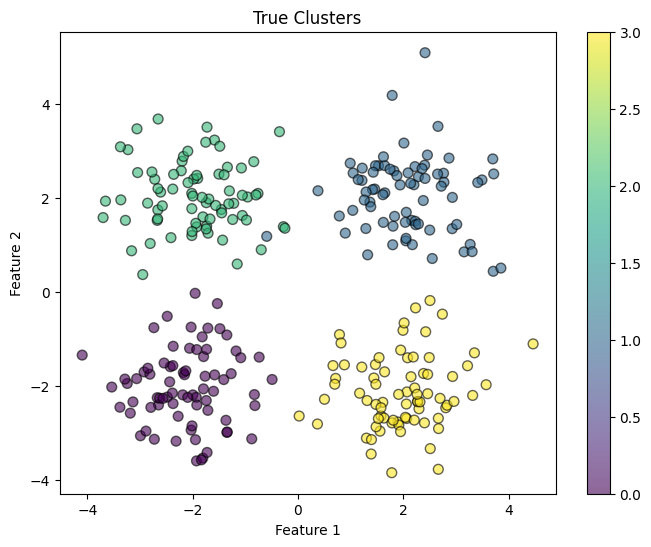

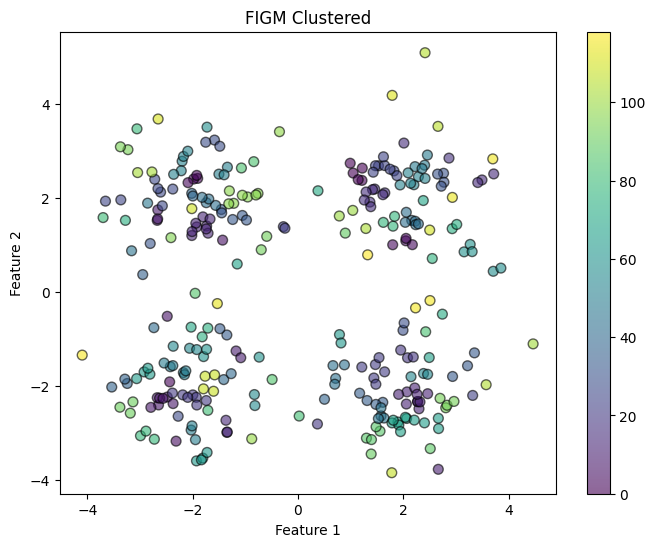

In [2]:
def plot_clusters(data, labels, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50, alpha=0.6)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.colorbar()
    plt.show()

# Generate synthetic data
centers = [[-2, -2], [2, 2], [-2, 2], [2, -2]]  # Define centers of clusters
cluster_std = [0.8, 0.8, 0.8, 0.8]  # Standard deviation of clusters
X, y_true = make_blobs(n_samples=300, centers=centers, cluster_std=cluster_std, random_state=42)

# Perform clustering using FIGM
dimension = 2
figm_components = cluster_data(X, dimension)

# Extract the labels from the components
y_pred = np.zeros(X.shape[0])
for idx, point in enumerate(X):
    distances = [mahalanobis_distance(point, comp) for comp in figm_components]
    y_pred[idx] = np.argmin(distances)

# Numerical evaluation using Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(y_true, y_pred)
print(f"Adjusted Rand Index: {ari_score:.4f}")

# Visual evaluation
plot_clusters(X, y_true, "True Clusters")
plot_clusters(X, y_pred, "FIGM Clustered")